In [26]:
import numpy as np
from numpy.polynomial import polynomial as P
from scipy import interpolate as ip
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import random
from symfit import parameters, variables, sin, cos, Fit
from scipy import signal
import pandas as pd
import scipy.integrate as integrate
import torch 
import torch.nn as nn

np.product = np.prod

In [2]:
def normalise(x, y, area=None):
    if area is None:
        area = integrate.simpson(y, x)
    y = y / area
    return y 

def normalise_error(x, y, y_err, area=None):
    if area is None:
        area = integrate.simpson(y, x)
    y = y_err / area
    return y

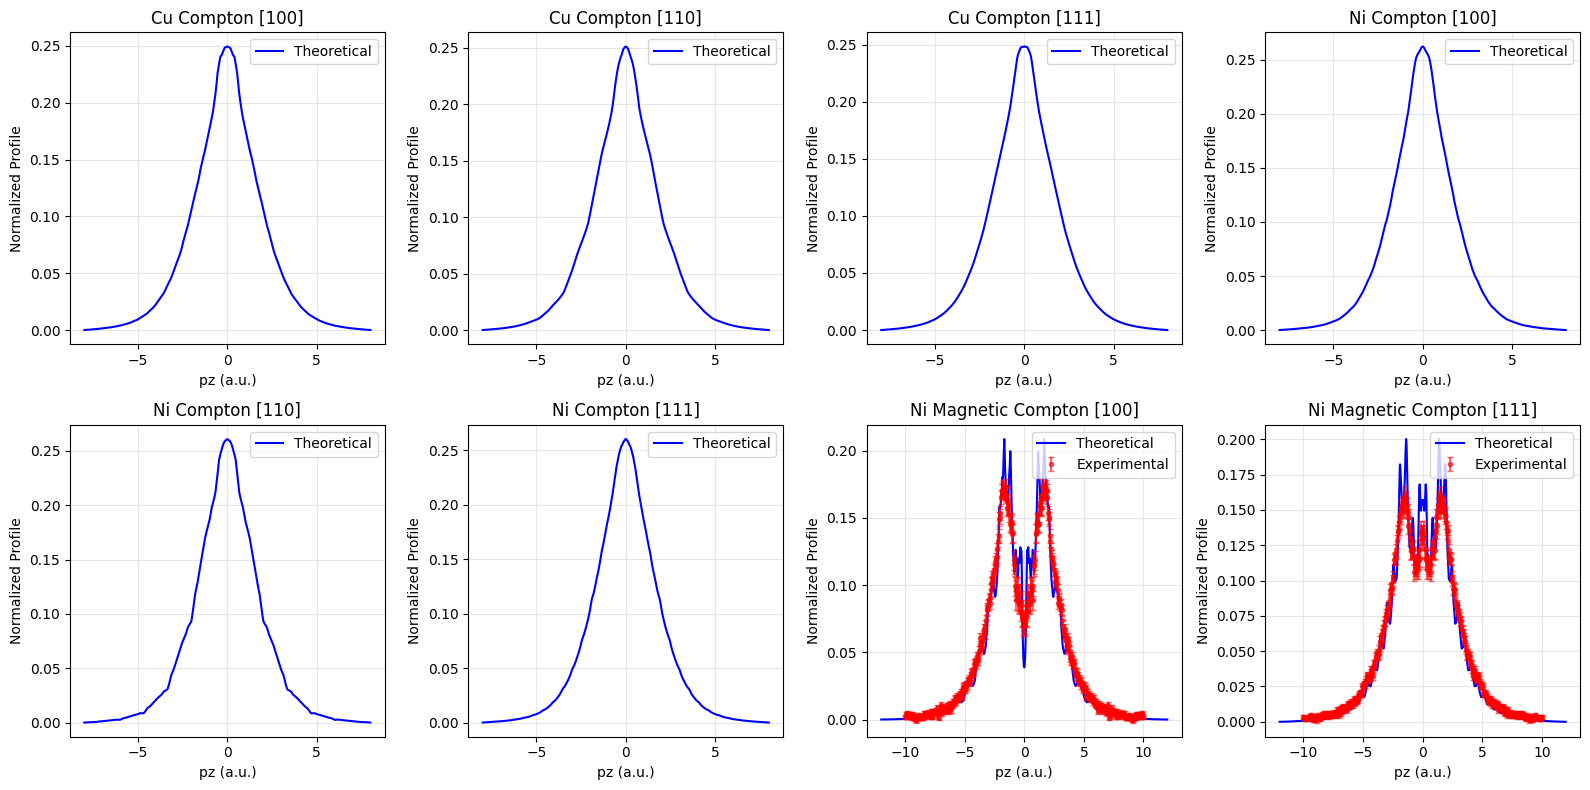

In [3]:
# Define base paths
magnetic_data_dir = 'Ni_Magnetic_Compton/'

# Orientations to load
orientations = ['100', '110', '111']

# Initialize 3D nested dictionary structure
df = {
    'Cu_Compton': {},
    'Ni_Compton': {},
    'Ni_Magnetic_Compton': {}
}

# Load Cu_Compton theoretical profiles (non-magnetic, spin-degenerate)
for orientation in orientations:
    cu_file = f'Cu_degen_spin/I_EMD1D.OUT_Cu_{orientation}'
    pz_cu, j_cu = np.loadtxt(cu_file, skiprows=1, unpack=True)
    
    # Normalize the profile
    j_cu_norm = normalise(pz_cu, j_cu)
    
    df['Cu_Compton'][orientation] = {
        'pz': pz_cu,
        'cp': j_cu,  # Compton profile J(pz)
        'cp_norm': j_cu_norm
    }

# Load Ni_Compton theoretical profiles (non-magnetic, spin-degenerate)
for orientation in orientations:
    ni_file = f'Ni_degen_spin/I_EMD1D.OUT_Ni_{orientation}'
    pz_ni, j_ni = np.loadtxt(ni_file, skiprows=1, unpack=True)
    
    # Normalize the profile
    j_ni_norm = normalise(pz_ni, j_ni)
    
    df['Ni_Compton'][orientation] = {
        'pz': pz_ni,
        'cp': j_ni,  # Compton profile J(pz)
        'cp_norm': j_ni_norm
    }

# Load Ni_Magnetic_Compton profiles (spin-resolved)
# Note: Only 100 and 111 orientations have data in Week13
magnetic_orientations = ['100', '111']

for orientation in magnetic_orientations:
    # Read theoretical data (DFT)
    theory_file = f'Ni_Magnetic_Compton/I_EMD1D.OUT.{orientation}'
    pz_theory, j_up, j_down = np.loadtxt(theory_file, skiprows=1, unpack=True)
    
    # Calculate magnetic Compton profile (spin up - spin down)
    mcp_theory = j_up - j_down
    
    # Normalize profiles
    j_up_norm = normalise(pz_theory, j_up)
    j_down_norm = normalise(pz_theory, j_down)
    mcp_theory_norm = normalise(pz_theory, mcp_theory)
    
    # Read experimental data
    exp_file = f'{magnetic_data_dir}ni{orientation}ts_witherrors.dat'
    pz_exp, mcp_exp, error_exp = np.loadtxt(exp_file, unpack=True)
    
    # Normalize experimental profile
    mcp_exp_norm = normalise(pz_exp, mcp_exp)
    error_exp_norm = normalise_error(pz_exp, mcp_exp, error_exp)
    
    df['Ni_Magnetic_Compton'][orientation] = {
        'theoretical': {
            'pz': pz_theory,
            'j_up': j_up,
            'j_down': j_down,
            'j_up_norm': j_up_norm,
            'j_down_norm': j_down_norm,
            'mcp': mcp_theory,
            'mcp_norm': mcp_theory_norm
        },
        'experimental': {
            'pz': pz_exp,
            'mcp': mcp_exp,
            'error': error_exp,
            'mcp_norm': mcp_exp_norm,
            'error_norm': error_exp_norm
        }
    }
    
# Print summary of loaded data - one subplot per (material, orientation) pair
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.flatten()

subplot_idx = 0
for material, orientations_dict in df.items():
    for orientation, data in orientations_dict.items():
        # Check if we're dealing with magnetic Compton (has 'theoretical' key) or regular (direct data)
        if 'theoretical' in data:
            # Ni_Magnetic_Compton case
            pz = data['theoretical']['pz']
            mcp_norm = data['theoretical']['mcp_norm']
            axs[subplot_idx].plot(pz, mcp_norm, label='Theoretical', color='blue')
            
            # Also plot experimental if available
            if 'experimental' in data:
                pz_exp = data['experimental']['pz']
                mcp_exp_norm = data['experimental']['mcp_norm']
                error_exp_norm = data['experimental']['error_norm']
                axs[subplot_idx].errorbar(pz_exp, mcp_exp_norm, yerr=error_exp_norm, 
                                         label='Experimental', color='red', alpha=0.6, 
                                         fmt='o', markersize=3, capsize=2)
        else:
            # Cu_Compton or Ni_Compton case
            pz = data['pz']
            cp_norm = data['cp_norm']
            axs[subplot_idx].plot(pz, cp_norm, label='Theoretical', color='blue')
        
        axs[subplot_idx].set_title(f'{material.replace("_", " ")} [{orientation}]')
        axs[subplot_idx].set_xlabel('pz (a.u.)')
        axs[subplot_idx].set_ylabel('Normalized Profile')
        axs[subplot_idx].legend()
        axs[subplot_idx].grid(True, alpha=0.3)
        
        subplot_idx += 1

plt.tight_layout()
plt.show()


In [4]:
def gaussian(x, amp, sig):
    return amp * np.exp(-x**2 / (2 * sig**2))

def gauss_model(x, n_gauss, *args):
    arr = np.zeros(x.shape)
    for i in range(n_gauss):
        arr += gaussian(x, *args[i*2:i*2+2])
    return arr

def fourier_series(x, frequency, order=0, f_0 = -.4):
     # Make the parameter objects for all the terms
    a0, *cos_a = parameters(','.join(['a{}'.format(i) for i in range(0, order + 1)]))
    sin_b = parameters(','.join(['b{}'.format(i) for i in range(1, order + 1)]))
    # Construct the series
    series = a0 + sum(ai * cos(i * frequency *f_0 * x) + bi * sin(i * frequency *f_0 * x)
    for i, (ai, bi) in enumerate(zip(cos_a, sin_b), start=1))
    return series


def fit_theoretical_profile(pz, cp, n_gaussians=3, fourier_order=40, fourier_strength=25, initial_guesses=None, verbose=True, fourier_steps=1):
    
    # Set default initial guesses if not provided
    if initial_guesses is None:
        if n_gaussians == 3:
            initial_guesses = [(0.8, 0.5), (0.2, 1.5), (0.1, 3.0)]
        else:
            # Generic initial guess: decreasing amplitudes, increasing widths
            initial_guesses = [(0.8 / (i+1), 0.5 * (i+1)) for i in range(n_gaussians)]
    
    # Flatten initial guess list
    p0 = [p for prms in initial_guesses for p in prms]
    
    # Define bounds for parameters
    lower_bounds = [0.0, 0.1] * n_gaussians
    upper_bounds = [1.0, 10.0] * n_gaussians
    
    # Create temporary model function for this specific n_gaussians
    def temp_model(x, *args):
        arr = np.zeros(x.shape)
        for i in range(n_gaussians):
            arr += gaussian(x, *args[i*2:i*2+2])
        return arr
    
    # Fit Gaussians using curve_fit
    popt, pcov = curve_fit(temp_model, pz, cp, p0,
                           bounds=(lower_bounds, upper_bounds),
                           method='trf',
                           max_nfev=1000000)
    
    # Reconstruct Gaussian fit
    gauss_fit = np.zeros(cp.shape)
    gauss_params = []
    for i in range(n_gaussians):
        amplitude, sigma = popt[i*2], popt[i*2+1]
        gauss_fit += gaussian(pz, amplitude, sigma)
        gauss_params.append((amplitude, sigma))
        
        if verbose:
            print(f'Gaussian {i+1}: Amplitude = {amplitude:.4f}, Sigma = {sigma:.4f}')
    
    # Calculate residuals
    residuals = cp - gauss_fit
    
    # Fit Fourier series to residuals
    x, y = variables('x, y')
    w, = parameters('w')
    model_dict = {y: fourier_series(x, w, fourier_order, f_0 = 1/fourier_steps)}
    fit = Fit(model_dict, x=pz, y=residuals)
    fit_result = fit.execute()
    
    if verbose:
        print(f'\nFourier Series Fit:')
        print(fit_result)
    
    # Generate Fourier component
    fourier_fit_raw = fit.model(x=pz, **fit_result.params).y
    fourier_fit_scaled = fourier_fit_raw * fourier_strength * gauss_fit
    
    # Complete fit (Gaussian + scaled Fourier)
    complete_fit = gauss_fit + fourier_fit_scaled 
    
    return {
        'gauss_params': gauss_params,
        'gauss_fit': gauss_fit,
        'fourier_params': fit_result.params,
        'fourier_strength': fourier_strength,
        'fourier_fit': fourier_fit_scaled,
        'fourier_fit_raw': fourier_fit_raw,
        'complete_fit': complete_fit,
        'residuals': residuals,
        'popt': popt,
        'pcov': pcov
    }

In [22]:
from Richardson_lucy_functions import gaussian_kernel_1D

def blur(y, res_fwhm, pz_min, pz_max, Npts):
    pz = np.linspace(pz_min, pz_max, Npts)
    grid_spacing = np.abs(pz[1] - pz[0])
    sigma = res_fwhm / (2 * np.sqrt(2 * np.log(2))) / grid_spacing
    kernel = gaussian_kernel_1D(size=201, sigma=sigma)
    y = signal.convolve(y, kernel, mode='same')
    return y

def noise(y, noise_scale=0.1):
    y_noisy = y + np.sqrt(np.abs(y)) * np.random.normal(0,noise_scale,size=y.shape)
    return y_noisy

def degrade_compton_profile(y, res_fwhm, pz_min=-10, pz_max=10, Npts=401, noise_level=0.1):
    y = blur(y, res_fwhm, pz_min, pz_max, Npts)
    y = noise(y, noise_level)
    return y

Gaussian 1: Amplitude = 0.0000, Sigma = 0.1187
Gaussian 2: Amplitude = 0.1399, Sigma = 2.6806
Gaussian 3: Amplitude = 0.0112, Sigma = 2.6809

Fourier Series Fit:

Parameter Value        Standard Deviation
a0        -1.210986e-03 3.913674e-04
a1        -7.453024e-03 5.647353e-04
a10       -8.467998e-04 5.508718e-04
a11       -2.379368e-04 5.565433e-04
a12       -1.050976e-03 5.816952e-04
a13       -3.694247e-03 5.571803e-04
a14       -7.184618e-04 5.559394e-04
a15       1.035702e-04 5.541270e-04
a16       -2.868471e-05 5.545840e-04
a17       -8.816157e-05 5.520490e-04
a18       2.195719e-04 5.526596e-04
a19       1.204683e-04 5.526127e-04
a2        -1.198942e-02 5.649518e-04
a20       5.836160e-05 5.618748e-04
a21       2.537763e-04 5.530659e-04
a22       1.164669e-04 5.545026e-04
a23       6.939399e-05 5.561772e-04
a24       4.962648e-05 5.565974e-04
a25       1.422809e-04 5.632455e-04
a26       1.086231e-03 5.570883e-04
a27       1.246157e-04 5.522974e-04
a28       6.358363e-05 5.5351

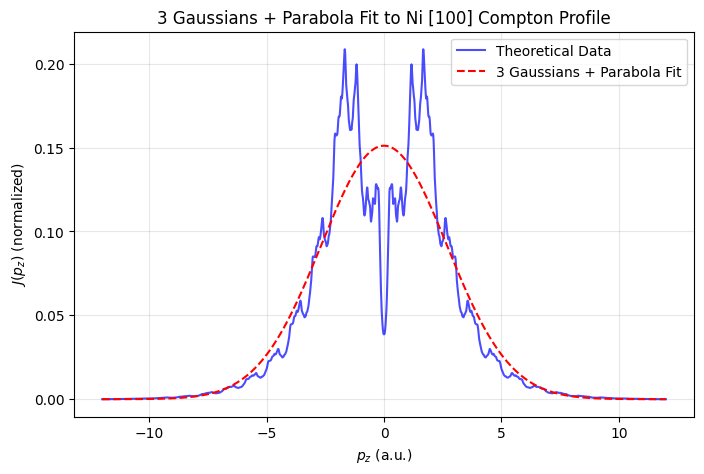

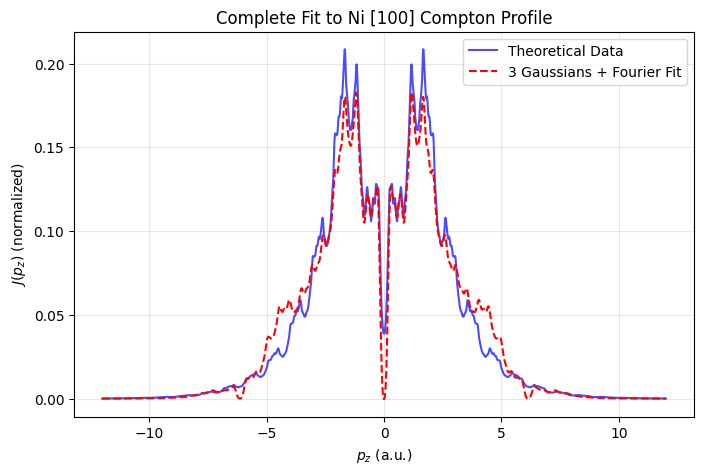

In [6]:
pz = df['Ni_Magnetic_Compton']['100']['theoretical']['pz']
cp = df['Ni_Magnetic_Compton']['100']['theoretical']['mcp_norm']

fourier_steps = 1
fourier_order = 35
fourier_strength = 25
# Fit the profile using the fit_theoretical_profile function
fit_result100 = fit_theoretical_profile(pz, cp, n_gaussians=3, fourier_order=fourier_order, fourier_strength=fourier_strength, fourier_steps=1, verbose=True)

# Plot Gaussian-only fit
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pz, cp, label='Theoretical Data', color='blue', alpha=0.7)
ax.plot(pz, fit_result100['gauss_fit'], label='3 Gaussians + Parabola Fit', color='red', linestyle='--')
ax.set_xlabel('$p_z$ (a.u.)')
ax.set_ylabel('$J(p_z)$ (normalized)')
ax.set_title('3 Gaussians + Parabola Fit to Ni [100] Compton Profile')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Plot complete fit with Fourier component
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pz, cp, label='Theoretical Data', color='blue', alpha=0.7)
ax.plot(pz, fit_result100['complete_fit'], label='3 Gaussians + Fourier Fit', color='red', linestyle='--')
ax.set_xlabel('$p_z$ (a.u.)')
ax.set_ylabel('$J(p_z)$ (normalized)')
ax.set_title('Complete Fit to Ni [100] Compton Profile')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

Gaussian 1: Amplitude = 0.0000, Sigma = 0.1094
Gaussian 2: Amplitude = 0.1421, Sigma = 2.5073
Gaussian 3: Amplitude = 0.0165, Sigma = 2.5074

Fourier Series Fit:

Parameter Value        Standard Deviation
a0        1.499888e-04 2.608099e-04
a1        -2.242277e-03 3.699555e-04
a10       1.192123e-04 3.714322e-04
a11       -5.691024e-03 3.687009e-04
a12       4.824196e-04 3.724036e-04
a13       6.623202e-04 3.688424e-04
a14       -1.707905e-04 3.690304e-04
a15       -3.603340e-04 3.689311e-04
a16       6.898417e-05 3.688673e-04
a17       9.757231e-05 3.686996e-04
a18       6.733888e-05 3.687319e-04
a19       9.242784e-05 3.687141e-04
a2        -5.707450e-03 3.691969e-04
a20       7.837860e-05 3.687401e-04
a21       2.874664e-04 3.695130e-04
a22       1.369744e-03 3.687125e-04
a23       6.219735e-05 3.689383e-04
a24       3.158686e-05 3.688332e-04
a25       1.936500e-04 3.687919e-04
a26       9.752308e-05 3.687617e-04
a27       -4.738840e-05 3.687124e-04
a28       6.871601e-07 3.687438e-

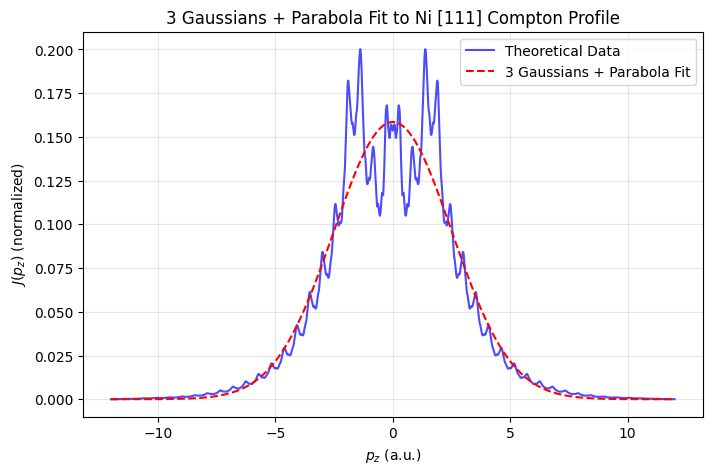

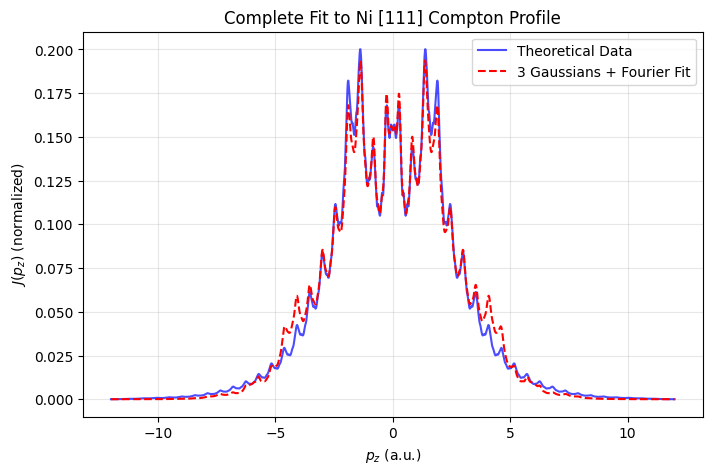

In [7]:
pz = df['Ni_Magnetic_Compton']['111']['theoretical']['pz']
cp = df['Ni_Magnetic_Compton']['111']['theoretical']['mcp_norm']

# Fit the profile using the fit_theoretical_profile function
fit_result111 = fit_theoretical_profile(pz, cp, n_gaussians=3, fourier_order=fourier_order, 
                                     fourier_strength=fourier_strength, verbose=True, fourier_steps=fourier_steps)


# Plot Gaussian-only fit
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pz, cp, label='Theoretical Data', color='blue', alpha=0.7)
ax.plot(pz, fit_result111['gauss_fit'], label='3 Gaussians + Parabola Fit', color='red', linestyle='--')
ax.set_xlabel('$p_z$ (a.u.)')
ax.set_ylabel('$J(p_z)$ (normalized)')
ax.set_title('3 Gaussians + Parabola Fit to Ni [111] Compton Profile')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Plot complete fit with Fourier component
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pz, cp, label='Theoretical Data', color='blue', alpha=0.7)
ax.plot(pz, fit_result111['complete_fit'], label='3 Gaussians + Fourier Fit', color='red', linestyle='--')
ax.set_xlabel('$p_z$ (a.u.)')
ax.set_ylabel('$J(p_z)$ (normalized)')
ax.set_title('Complete Fit to Ni [111] Compton Profile')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [8]:
exp_y = df['Ni_Magnetic_Compton']['100']['experimental']['mcp_norm']
pz_e = df['Ni_Magnetic_Compton']['100']['experimental']['pz']

def GenerateSyntheticProfile(pz, gauss_params, fourier_params, fourier_order=50, f_0=0.4, FWHM=0.4, noise_scale=None):
    def get_param_value(param):
        return param.value if hasattr(param, 'value') else param

    # Gaussian component
    gauss_profile = np.zeros_like(pz)
    for amplitude, sigma in gauss_params:
        gauss_profile += gaussian(pz, amplitude, sigma)

    # Fourier component
    a0_val = get_param_value(fourier_params['a0'])
    w_val = get_param_value(fourier_params['w'])
    fourier_profile = a0_val * np.ones_like(pz)
    for i in range(1, fourier_order + 1):
        ai_val = get_param_value(fourier_params[f'a{i}'])
        bi_val = get_param_value(fourier_params[f'b{i}'])
        fourier_profile += ai_val * np.cos(i * w_val * f_0 * pz) + bi_val * np.sin(i * w_val * f_0 * pz)

    fourier_profile_scaled = fourier_profile * fit_result100['fourier_strength'] * gauss_profile

    mask = (pz >= pz_e.min()) & (pz <= pz_e.max())
    gauss_profile = gauss_profile[mask][::5]
    fourier_profile_scaled = fourier_profile_scaled[mask][::5]

    synthetic_profile = np.array(gauss_profile) + np.array(fourier_profile_scaled)
    if synthetic_profile.min() < 0:
        return None, None

    try:
        # Bug fix 2: pass noise_scale not noise_level
        # Bug fix 3: degrade_compton_profile returns single value, not tuple
        synthetic_profile_degraded = degrade_compton_profile(
            synthetic_profile, FWHM, noise_level=noise_scale if noise_scale is not None else 0.1
        )
    except Exception as e:
        print(f"Error generating degraded profile: {e}")
        return None, None

    return normalise(pz_e, synthetic_profile), normalise(pz_e, synthetic_profile_degraded)

In [9]:
# Store all parameters in a pandas dataframe

fit_results_list = [
    {"orientation": "100", **fit_result100},
    {"orientation": "111", **fit_result111}
]
params_df = pd.DataFrame(fit_results_list)

fig.tight_layout()
params_df.head()

,orientation,gauss_params,gauss_fit,fourier_params,fourier_strength,fourier_fit,fourier_fit_raw,complete_fit,residuals,popt,pcov
0,100,"[(6.65013101136654e-19, 0.11865526038072258), ...","[6.726565260707548e-06, 6.839790198803969e-06,...","{'a0': -0.001210985538657134, 'a1': -0.0074530...",25,"[-1.1524218031113346e-06, -1.1037016160641005e...","[-0.006852958432399806, -0.0064545933953184574...","[5.574143457596213e-06, 5.736088582739868e-06,...","[-6.726552967739088e-06, -6.576304298556449e-0...","[6.65013101136654e-19, 0.11865526038072258, 0....","[[2.6805085687719996e-05, -2.0856039386961546e..."
1,111,"[(2.7937403959098756e-10, 0.10941427250209006)...","[1.6835998529765404e-06, 1.7160315468044577e-0...","{'a0': 0.00014998883411034144, 'a1': -0.002242...",25,"[-4.7162272431817194e-08, -4.785349799795704e-...","[-0.0011205102530375277, -0.001115445647536454...","[1.6364375805447231e-06, 1.6681780488065007e-0...","[-1.6835771045046292e-06, -1.3188054159548389e...","[2.7937403959098756e-10, 0.10941427250209006, ...","[[1.5424345280783962e-05, -2636.5542300580914,..."


In [23]:
fourier_spread = 1.0
gauss_spread = 1.0
N_profiles = 7000
noise_scale = 0.01
FWHM = 0.3

# Calculate differences in Gaussian parameters between the two profiles
gauss_difference = np.array(params_df.loc[0]['gauss_params']) - np.array(params_df.loc[1]['gauss_params'])

# Calculate differences in Fourier parameters between the two profiles
fourier_0 = params_df.loc[0]['fourier_params']
fourier_1 = params_df.loc[1]['fourier_params']
odd_sucess = 0
even_sucess = 0
fourier_difference = {}
for param_name in fourier_0.keys():
    diff = fourier_0[param_name] - fourier_1[param_name]
    fourier_difference[param_name] = diff

# Generate N_profiles synthetic profiles with randomized parameters
clean_profiles = []
degraded_profiles = []
attempts = 0
max_attempts = N_profiles * 10  # Prevent infinite loop

while len(clean_profiles) < N_profiles and attempts < max_attempts:
    attempts += 1
    
    # Create test Gaussian parameters by randomly varying the original parameters
    test_gauss_params = []
    for i in range(3):
        amp_diff = gauss_difference[i][0]
        sigma_diff = gauss_difference[i][1]
        
        # Randomly vary the parameters within a certain spread
        amp_variation = random.uniform(-gauss_spread, gauss_spread) * amp_diff * fourier_spread
        sigma_variation = random.uniform(-gauss_spread, gauss_spread) * sigma_diff * fourier_spread
        
        if attempts % 2 == 0:
            test_amp = params_df.loc[0]['gauss_params'][i][0] + amp_variation
            test_sigma = params_df.loc[0]['gauss_params'][i][1] + sigma_variation
        else:
            test_amp = params_df.loc[1]['gauss_params'][i][0] + amp_variation
            test_sigma = params_df.loc[1]['gauss_params'][i][1] + sigma_variation
        
        test_gauss_params.append((test_amp, test_sigma))
    
    # Create test Fourier parameters by randomly varying the original parameters
    test_fourier_params = {}
    if attempts % 2 == 0:
        fourier_base = fourier_0
    else:
        fourier_base = fourier_1
    for param_name in fourier_base.keys():
        original_value = fourier_base[param_name]
        diff = fourier_difference[param_name]
        
        # Randomly vary the parameter within a certain spread
        variation = random.uniform(-fourier_spread, fourier_spread) * diff * fourier_spread
        test_fourier_params[param_name] = original_value + variation
    
    # Generate the synthetic profile
    noise_val = noise_scale #+ random.uniform(-noise_variation, noise_variation)
    #print(noise)
    test_profile, degraded_profile = GenerateSyntheticProfile(pz, test_gauss_params, test_fourier_params, fourier_order=fourier_order, f_0=1/fourier_steps, FWHM = FWHM, noise_scale = noise_val)
    if test_profile is not None and degraded_profile is not None:
        clean_profiles.append(test_profile)
        degraded_profiles.append(degraded_profile)
        if attempts % 2 == 0:
            even_sucess += 1
        else:
            odd_sucess += 1
print("Even attempts successful:", even_sucess)
print("Odd attempts successful:", odd_sucess)
print(f"Generated {len(clean_profiles)} valid synthetic profiles (out of {attempts} attempts)")


Even attempts successful: 2302
Odd attempts successful: 4698
Generated 7000 valid synthetic profiles (out of 9396 attempts)


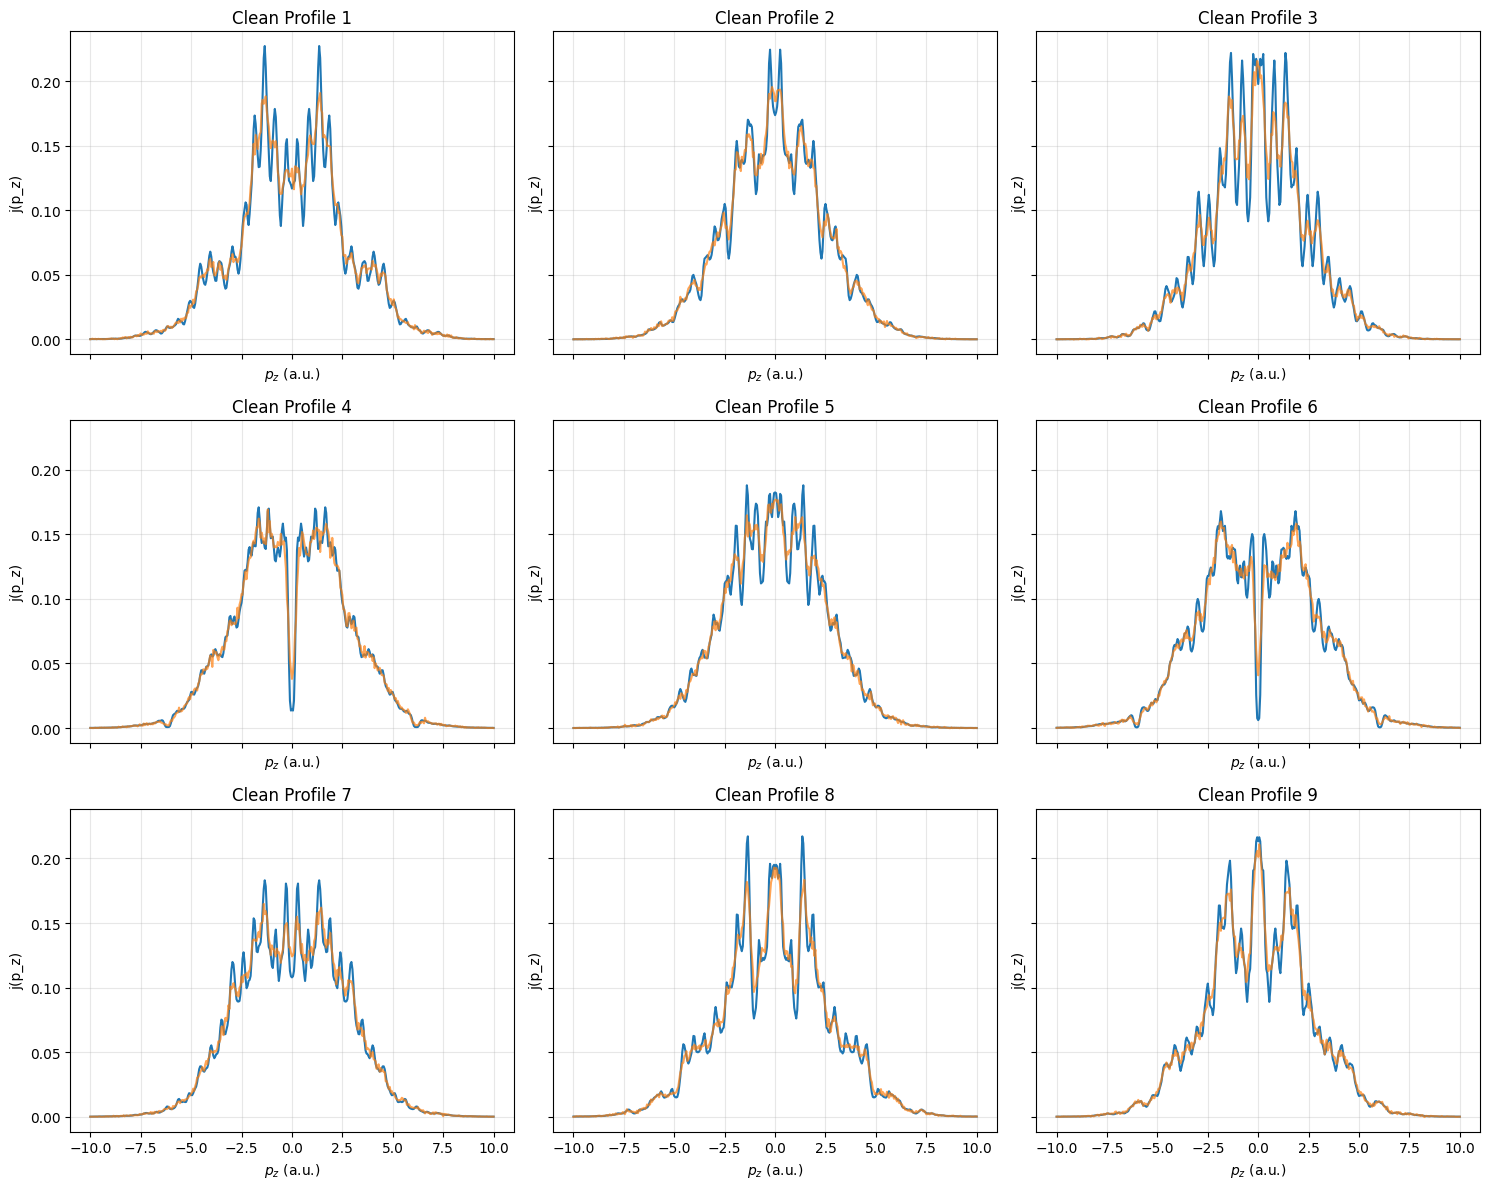

In [24]:
fig, axs = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
axs = axs.flatten()

# Display up to 9 profiles
n_display = min(9, len(clean_profiles))

for i in range(n_display):
    test_profile = clean_profiles[i]
    axs[i].plot(pz_e, clean_profiles[i], linewidth=1.5)
    axs[i].plot(pz_e, degraded_profiles[i], linewidth=1.5, alpha=0.7)
    axs[i].set_title(f'Clean Profile {i+1}')
    axs[i].set_xlabel('$p_z$ (a.u.)')
    axs[i].set_ylabel('j(p_z)')
    axs[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## U-net

In [32]:
from models_and_training_functions import train_model, visualise_training, validate_and_visualise
from sklearn.model_selection import train_test_split

class DeblurUnet(nn.Module):
    def __init__(self):
        super(DeblurUnet, self).__init__()
        
        self.enc1 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.ReLU(),)
        
        self.enc2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.enc3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.dec1 = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.dec2 = nn.Sequential(
            nn.Conv1d(256, 64, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.dec3 = nn.Sequential(
            nn.Conv1d(128, 64, kernel_size=5, padding=2),
            nn.ReLU(),)

        self.final = nn.Conv1d(64, 1, kernel_size=7, padding=3)        
    
    def forward(self, x):
        x_input = x.unsqueeze(1)
        e1 = self.enc1(x_input)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        d1 = self.dec1(e3)
        d2 = self.dec2(torch.cat([d1, e2], dim=1))
        d3 = self.dec3(torch.cat([d2, e1], dim=1))
        output = self.final(d3)
        output = output.squeeze(1)
        output = x + 0.1 * output
        return output
    
    

In [ ]:
test_size = 0.2
seed = 42

X = np.stack(degraded_profiles)  # Degraded profiles (inputs)    
y = np.stack(clean_profiles)     # Clean profiles (targets)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

In [34]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=1000, batch_size=32, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50, factor=0.5)

    train_losses = []
    test_losses = []
    
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * inputs.size(0)

        avg_train_loss = epoch_loss / len(X_train)
        train_losses.append(avg_train_loss)
        
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test).item()
            test_losses.append(test_loss)
        
        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {test_loss:.4f}')
    
    return train_losses, test_losses


# Function to visualise training progress
def visualise_training(train_losses, test_losses):

    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('MSE Loss', fontsize=12)
    plt.yscale('log')
    plt.title('Training and Test Loss Over Time', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nFinal Training Loss: {train_losses[-1]:.6f}")
    print(f"Final Test Loss: {test_losses[-1]:.6f}")


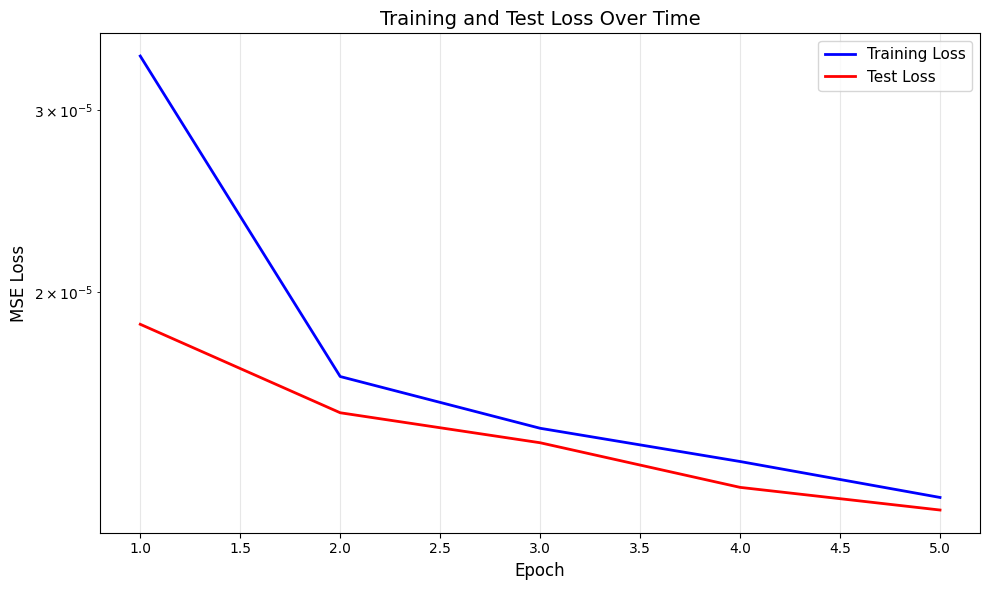


Final Training Loss: 0.000013
Final Test Loss: 0.000012


In [35]:
model = DeblurUnet()

train_losses, test_losses = train_model(model=model,X_train=X_train,y_train=y_train, X_test=X_test,
                                         y_test=y_test, epochs=5, batch_size=32, lr=0.001)

visualise_training(train_losses, test_losses)



TEST SET EVALUATION
Number of test samples: 1400
Average MSE: 0.000012
Average MAE: 0.002062
Std MSE: 0.000004
Min MSE: 0.000004
Max MSE: 0.000031


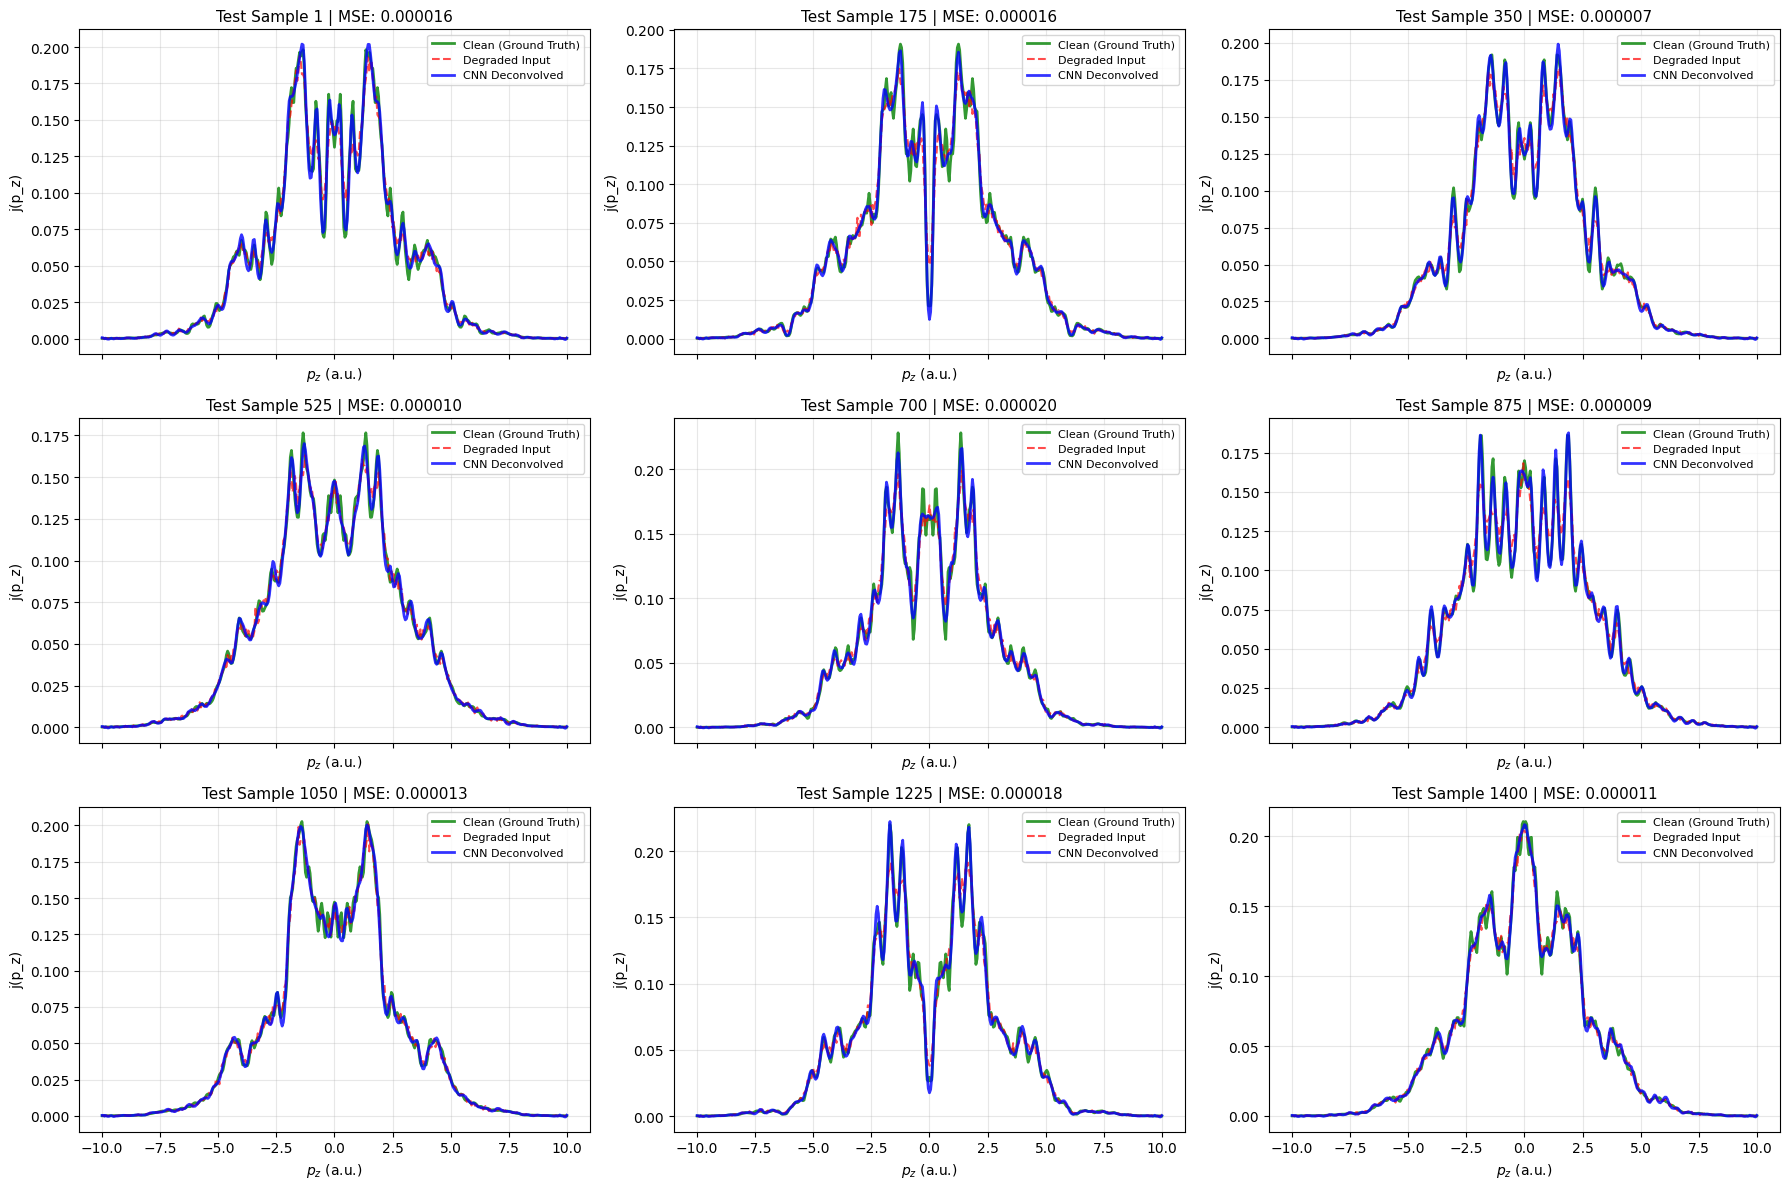

In [36]:
# Evaluate on test set
model.eval()

with torch.no_grad():
    # Get predictions for all test samples
    test_predictions = model(X_test).numpy()
    test_clean = y_test.numpy()
    test_degraded = X_test.numpy()
    
    # Calculate metrics
    mse_per_sample = np.mean((test_predictions - test_clean)**2, axis=1)
    mae_per_sample = np.mean(np.abs(test_predictions - test_clean), axis=1)
    
    print("\n" + "=" * 60)
    print("TEST SET EVALUATION")
    print("=" * 60)
    print(f"Number of test samples: {len(test_predictions)}")
    print(f"Average MSE: {np.mean(mse_per_sample):.6f}")
    print(f"Average MAE: {np.mean(mae_per_sample):.6f}")
    print(f"Std MSE: {np.std(mse_per_sample):.6f}")
    print(f"Min MSE: {np.min(mse_per_sample):.6f}")
    print(f"Max MSE: {np.max(mse_per_sample):.6f}")
    print("=" * 60)

# Plot 9 examples from test set
fig, axs = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
axs = axs.flatten()

n_display = min(9, len(test_predictions))
display_indices = np.linspace(0, len(test_predictions)-1, n_display, dtype=int)

for i, idx in enumerate(display_indices):
    ax = axs[i]
    
    ax.plot(pz_e, test_clean[idx], 'g-', label='Clean (Ground Truth)', 
            linewidth=2, alpha=0.8)
    ax.plot(pz_e, test_degraded[idx], 'r--', label='Degraded Input', 
            linewidth=1.5, alpha=0.7)
    ax.plot(pz_e, test_predictions[idx], 'b-', label='CNN Deconvolved', 
            linewidth=2, alpha=0.8)
    
    ax.set_title(f'Test Sample {idx+1} | MSE: {mse_per_sample[idx]:.6f}', 
                fontsize=11)
    ax.set_xlabel('$p_z$ (a.u.)', fontsize=10)
    ax.set_ylabel('j(p_z)', fontsize=10)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

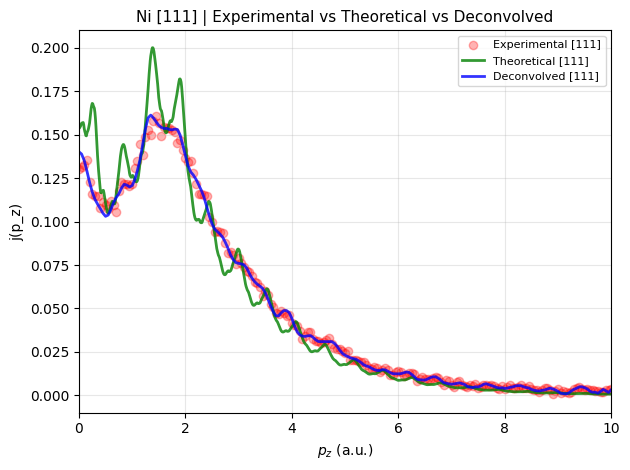

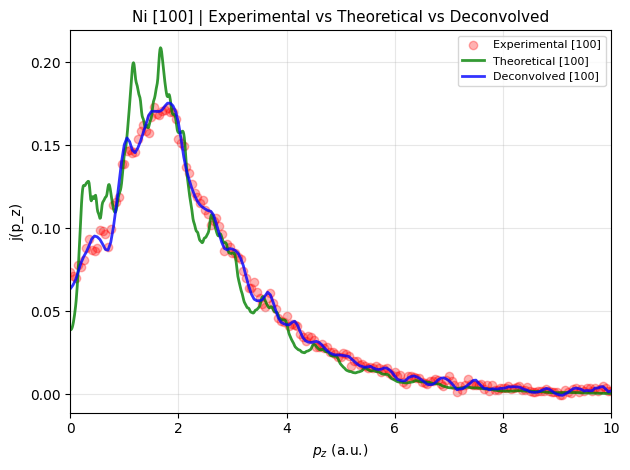

In [37]:
experimental111 = df['Ni_Magnetic_Compton']['111']['experimental']['mcp_norm']
theoretical111 = df['Ni_Magnetic_Compton']['111']['theoretical']['mcp_norm']
pz_t = df['Ni_Magnetic_Compton']['111']['theoretical']['pz']

# normalise experimental111 and theoretical111 between 0 and 1
#experimental111 = (experimental111 - theoretical111.min()) / (theoretical111.max() - theoretical111.min()) 
# normalise experimental111 by area
experimental111 = normalise(pz_e, experimental111)
theoretical111 = normalise(pz_t, theoretical111)

# convert to tensors
experimental111 = torch.FloatTensor(experimental111)
theoretical111 = torch.FloatTensor(theoretical111)

model.eval()
with torch.no_grad():
    deconvolved111 = model(experimental111.unsqueeze(0)).squeeze(0)


pz_t = df['Ni_Magnetic_Compton']['111']['theoretical']['pz']
pz_e = df['Ni_Magnetic_Compton']['111']['experimental']['pz']

fig, ax = plt.subplots()
ax.scatter(pz_e, experimental111, c = 'r', label='Experimental [111]', alpha=0.3)
ax.plot(pz_t, theoretical111, 'g-', label='Theoretical [111]', linewidth=2, alpha=0.8)
ax.plot(pz_e, deconvolved111.detach().numpy(), 'b-', label='Deconvolved [111]', linewidth=2, alpha=0.8)
ax.set_title('Ni [111] | Experimental vs Theoretical vs Deconvolved', fontsize=11)
ax.set_xlabel('$p_z$ (a.u.)', fontsize=10)
ax.set_ylabel('j(p_z)', fontsize=10)
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, pz_e.max())
fig.tight_layout()
fig.savefig('Ni_111_Deconvolution.png', dpi=300)

experimental100 = df['Ni_Magnetic_Compton']['100']['experimental']['mcp_norm']
theoretical100 = df['Ni_Magnetic_Compton']['100']['theoretical']['mcp_norm']

# normalise experimental100 and theoretical100 to have area 0
experimental100 = normalise(pz_e, experimental100)
theoretical100 = normalise(pz_t, theoretical100)

# convert to tensors
experimental100 = torch.FloatTensor(experimental100)
theoretical100 = torch.FloatTensor(theoretical100)

pz_t = df['Ni_Magnetic_Compton']['100']['theoretical']['pz']
pz_e = df['Ni_Magnetic_Compton']['100']['experimental']['pz']
deconvolved100 = model(torch.FloatTensor(experimental100).unsqueeze(0)).squeeze(0)

fig, ax = plt.subplots()
ax.scatter(pz_e, experimental100, c = 'r', label='Experimental [100]', alpha=0.3)
ax.plot(pz_t, theoretical100, 'g-', label='Theoretical [100]', linewidth=2, alpha=0.8)
ax.plot(pz_e, deconvolved100.detach().numpy(), 'b-', label='Deconvolved [100]', linewidth=2, alpha=0.8)
ax.set_title('Ni [100] | Experimental vs Theoretical vs Deconvolved', fontsize=11)
ax.set_xlabel('$p_z$ (a.u.)', fontsize=10)
ax.set_ylabel('j(p_z)', fontsize=10)
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, pz_e.max())
fig.tight_layout()
fig.savefig('Ni_100_Deconvolution.png', dpi=300)